In [10]:
print("Football analytics journey starts here!")

Football analytics journey starts here!


In [11]:
import os
os.getcwd()

'/content'

In [12]:
import pandas as pd

In [13]:
pd.__version__

'2.2.3'

In [14]:
# Premier League Team Styles Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [15]:
# Check our Python environment and pandas

print("Python environment is ready.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python environment is ready.
Pandas version: 2.2.3
NumPy version: 2.1.3


In [16]:
import pandas as pd

url = "https://www.football-data.co.uk/mmz4281/2526/E0.csv"

df = pd.read_csv(url)

print(f"Data loaded successfully! Rows: {len(df)}, Columns: {len(df.columns)}")

Data loaded successfully! Rows: 380, Columns: 132


In [17]:
url = "https://www.football-data.co.uk/mmz4281/2526/E0.csv"

df = pd.read_csv(url)

print("Data loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Data loaded successfully!
Rows: 380
Columns: 132


In [18]:
# Inspect the dataset

print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92



Column names:
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'Max

In [19]:
# Build team-level statistics from match data

home = df[[
    "HomeTeam", "FTHG", "FTAG", "HS", "HST", "HC", "HF", "HY", "HR"
]].copy()

home.columns = [
    "Team", "GoalsFor", "GoalsAgainst", "Shots", "ShotsOnTarget",
    "Corners", "Fouls", "YellowCards", "RedCards"
]

away = df[[
    "AwayTeam", "FTAG", "FTHG", "AS", "AST", "AC", "AF", "AY", "AR"
]].copy()

away.columns = [
    "Team", "GoalsFor", "GoalsAgainst", "Shots", "ShotsOnTarget",
    "Corners", "Fouls", "YellowCards", "RedCards"
]

# Combine home and away performances
team_data = pd.concat([home, away], ignore_index=True)

# Aggregate by team
team_stats = team_data.groupby("Team").agg(
    Matches=("Team", "count"),
    GoalsFor=("GoalsFor", "sum"),
    GoalsAgainst=("GoalsAgainst", "sum"),
    Shots=("Shots", "sum"),
    ShotsOnTarget=("ShotsOnTarget", "sum"),
    Corners=("Corners", "sum"),
    Fouls=("Fouls", "sum"),
    YellowCards=("YellowCards", "sum"),
    RedCards=("RedCards", "sum")
).reset_index()

# Calculate per-match metrics
metrics = [
    "GoalsFor",
    "GoalsAgainst",
    "Shots",
    "ShotsOnTarget",
    "Corners",
    "Fouls",
    "YellowCards",
    "RedCards"
]

for metric in metrics:
    team_stats[f"{metric}_PerMatch"] = (
        team_stats[metric] / team_stats["Matches"]
    )

# Display the resulting team dataset
display(team_stats.round(2))

,Team,Matches,GoalsFor,GoalsAgainst,Shots,ShotsOnTarget,Corners,Fouls,YellowCards,RedCards,GoalsFor_PerMatch,GoalsAgainst_PerMatch,Shots_PerMatch,ShotsOnTarget_PerMatch,Corners_PerMatch,Fouls_PerMatch,YellowCards_PerMatch,RedCards_PerMatch
0,Arsenal,38,71,27,552,186,216,391,51,0,1.87,0.71,14.53,4.89,5.68,10.29,1.34,0.00
1,Aston Villa,38,56,49,483,170,199,379,58,1,1.47,1.29,12.71,4.47,5.24,9.97,1.53,0.03
2,Bournemouth,38,58,54,525,178,212,457,88,2,1.53,1.42,13.82,4.68,5.58,12.03,2.32,0.05
3,Brentford,38,55,52,405,147,182,390,69,0,1.45,1.37,10.66,3.87,4.79,10.26,1.82,0.00
4,Brighton,38,52,46,495,176,185,453,86,0,1.37,1.21,13.03,4.63,4.87,11.92,2.26,0.00
5,Burnley,38,38,75,355,118,138,394,64,2,1.00,1.97,9.34,3.11,3.63,10.37,1.68,0.05
6,Chelsea,38,58,52,511,164,231,426,89,7,1.53,1.37,13.45,4.32,6.08,11.21,2.34,0.18
7,Crystal Palace,38,41,51,442,141,160,398,74,2,1.08,1.34,11.63,3.71,4.21,10.47,1.95,0.05
8,Everton,38,47,50,420,144,163,405,73,5,1.24,1.32,11.05,3.79,4.29,10.66,1.92,0.13
9,Fulham,38,47,51,481,138,188,414,75,1,1.24,1.34,12.66,3.63,4.95,10.89,1.97,0.03


In [20]:
# Create the key metrics for team style analysis

style_stats = team_stats[
    [
        "Team",
        "GoalsFor_PerMatch",
        "GoalsAgainst_PerMatch",
        "Shots_PerMatch",
        "ShotsOnTarget_PerMatch",
        "Corners_PerMatch",
        "Fouls_PerMatch",
        "YellowCards_PerMatch",
        "RedCards_PerMatch"
    ]
].copy()

# Rename columns to make them easier to understand
style_stats.columns = [
    "Team",
    "GoalsPerMatch",
    "GoalsConcededPerMatch",
    "ShotsPerMatch",
    "ShotsOnTargetPerMatch",
    "CornersPerMatch",
    "FoulsPerMatch",
    "YellowCardsPerMatch",
    "RedCardsPerMatch"
]

display(style_stats.round(2))

,Team,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch
0,Arsenal,1.87,0.71,14.53,4.89,5.68,10.29,1.34,0.00
1,Aston Villa,1.47,1.29,12.71,4.47,5.24,9.97,1.53,0.03
2,Bournemouth,1.53,1.42,13.82,4.68,5.58,12.03,2.32,0.05
3,Brentford,1.45,1.37,10.66,3.87,4.79,10.26,1.82,0.00
4,Brighton,1.37,1.21,13.03,4.63,4.87,11.92,2.26,0.00
5,Burnley,1.00,1.97,9.34,3.11,3.63,10.37,1.68,0.05
6,Chelsea,1.53,1.37,13.45,4.32,6.08,11.21,2.34,0.18
7,Crystal Palace,1.08,1.34,11.63,3.71,4.21,10.47,1.95,0.05
8,Everton,1.24,1.32,11.05,3.79,4.29,10.66,1.92,0.13
9,Fulham,1.24,1.34,12.66,3.63,4.95,10.89,1.97,0.03


In [21]:
from sklearn.preprocessing import StandardScaler

# Select the variables we will use to describe playing style
style_features = [
    "GoalsPerMatch",
    "GoalsConcededPerMatch",
    "ShotsPerMatch",
    "ShotsOnTargetPerMatch",
    "CornersPerMatch",
    "FoulsPerMatch",
    "YellowCardsPerMatch",
    "RedCardsPerMatch"
]

# Standardise the variables
scaler = StandardScaler()

X = scaler.fit_transform(style_stats[style_features])

print("Standardisation complete!")
print(f"Shape of analysis matrix: {X.shape}")

Standardisation complete!
Shape of analysis matrix: (20, 8)


In [22]:
from sklearn.cluster import KMeans

# Create 4 team-style clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

style_stats["Cluster"] = kmeans.fit_predict(X)

print("Clustering complete!")
print("\nTeams per cluster:")
print(style_stats["Cluster"].value_counts().sort_index())

Clustering complete!

Teams per cluster:
Cluster
0    4
1    5
2    4
3    7
Name: count, dtype: int64


In [23]:
# See which teams belong to each cluster

for cluster in sorted(style_stats["Cluster"].unique()):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*50}")

    teams = style_stats.loc[
        style_stats["Cluster"] == cluster, "Team"
    ].tolist()

    print(", ".join(teams))


CLUSTER 0
Arsenal, Liverpool, Man City, Man United

CLUSTER 1
Burnley, Everton, Sunderland, West Ham, Wolves

CLUSTER 2
Bournemouth, Brighton, Chelsea, Tottenham

CLUSTER 3
Aston Villa, Brentford, Crystal Palace, Fulham, Leeds, Newcastle, Nott'm Forest


In [24]:
# Calculate the average style profile of each cluster

cluster_profiles = style_stats.groupby("Cluster")[style_features].mean()

# Display the profiles
display(cluster_profiles.round(2))

,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch
Cluster,,,,,,,,
0,1.84,1.09,15.34,5.14,5.77,10.08,1.56,0.03
1,1.05,1.61,10.23,3.44,3.99,11.16,1.91,0.08
2,1.42,1.38,12.94,4.39,5.50,11.84,2.39,0.08
3,1.31,1.37,12.24,4.06,4.99,10.42,1.73,0.03


In [25]:
from sklearn.decomposition import PCA

# Reduce our 8 style variables to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Add the two PCA dimensions to our team dataset
style_stats["PCA1"] = X_pca[:, 0]
style_stats["PCA2"] = X_pca[:, 1]

print("PCA complete!")
print(f"Variance explained by PCA1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PCA2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

PCA complete!
Variance explained by PCA1: 56.5%
Variance explained by PCA2: 19.9%
Total variance explained: 76.3%


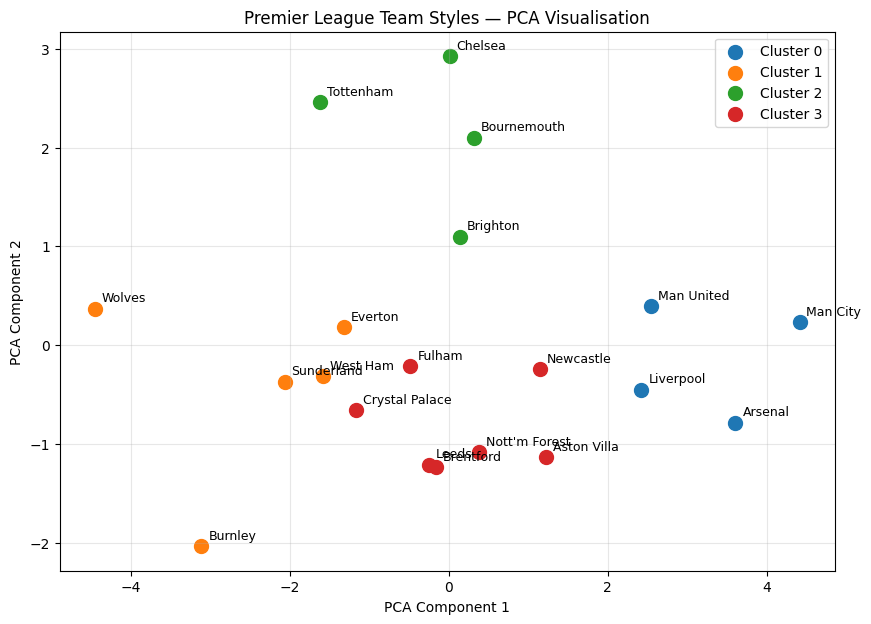

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for cluster in sorted(style_stats["Cluster"].unique()):
    cluster_data = style_stats[style_stats["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        s=100
    )

    # Add team names to each point
    for _, row in cluster_data.iterrows():
        plt.annotate(
            row["Team"],
            (row["PCA1"], row["PCA2"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Premier League Team Styles — PCA Visualisation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [27]:
# Understand which football metrics drive each PCA component

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=style_features,
    columns=["PCA1", "PCA2"]
)

print("PCA Loadings:")
display(pca_loadings.round(3))

PCA Loadings:


,PCA1,PCA2
GoalsPerMatch,0.450,0.122
GoalsConcededPerMatch,-0.365,-0.062
ShotsPerMatch,0.430,0.195
ShotsOnTargetPerMatch,0.423,0.207
CornersPerMatch,0.369,0.292
FoulsPerMatch,-0.284,0.479
YellowCardsPerMatch,-0.217,0.633
RedCardsPerMatch,-0.192,0.430


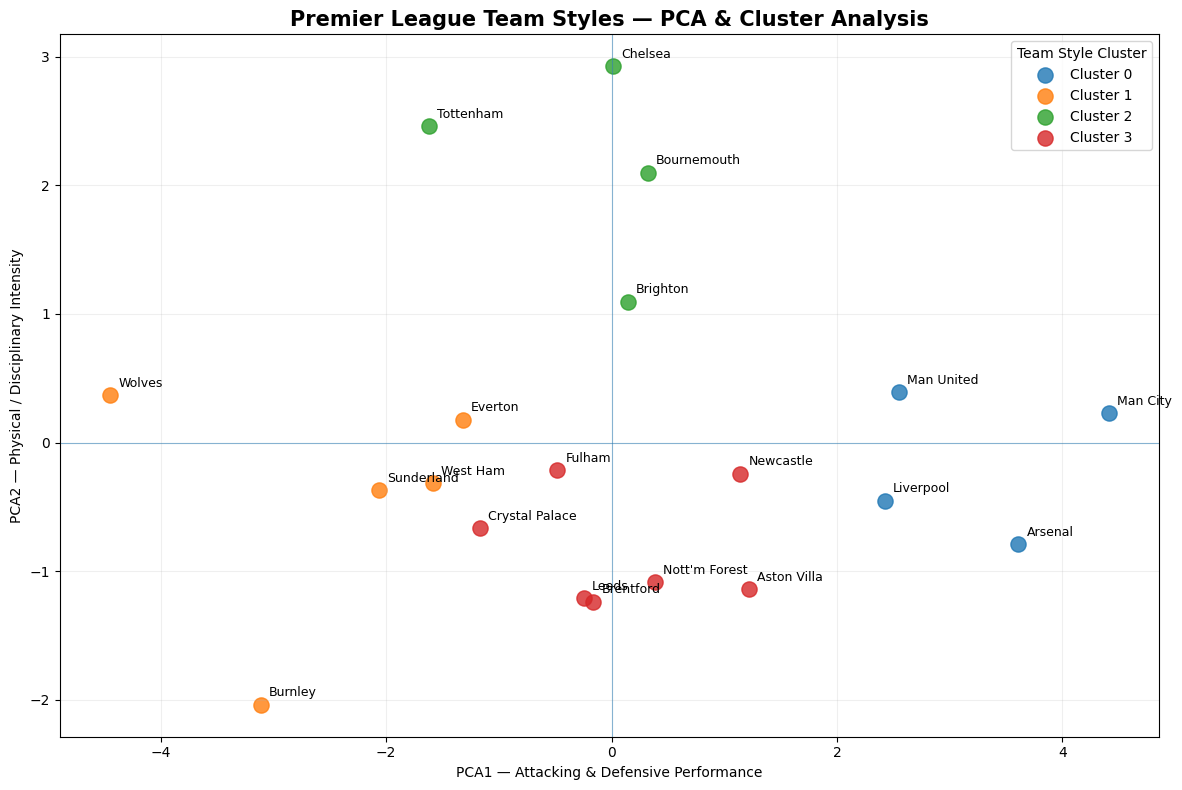

In [28]:
plt.figure(figsize=(12, 8))

for cluster in sorted(style_stats["Cluster"].unique()):
    cluster_data = style_stats[style_stats["Cluster"] == cluster]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=120,
        label=f"Cluster {cluster}",
        alpha=0.8
    )

    for _, row in cluster_data.iterrows():
        plt.annotate(
            row["Team"],
            (row["PCA1"], row["PCA2"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

plt.axhline(0, linewidth=0.8, alpha=0.5)
plt.axvline(0, linewidth=0.8, alpha=0.5)

plt.xlabel("PCA1 — Attacking & Defensive Performance")
plt.ylabel("PCA2 — Physical / Disciplinary Intensity")

plt.title(
    "Premier League Team Styles — PCA & Cluster Analysis",
    fontsize=15,
    fontweight="bold"
)

plt.legend(title="Team Style Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [29]:
# Compare each cluster against the overall league average

cluster_comparison = cluster_profiles.copy()

league_average = style_stats[style_features].mean()

# Difference from league average
cluster_difference = cluster_comparison - league_average

print("Cluster profile relative to league average:")
display(cluster_difference.round(2))

Cluster profile relative to league average:


,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch
Cluster,,,,,,,,
0,0.47,-0.29,2.84,0.96,0.77,-0.74,-0.31,-0.03
1,-0.32,0.24,-2.27,-0.75,-1.00,0.34,0.03,0.03
2,0.05,0.00,0.44,0.21,0.50,1.01,0.52,0.03
3,-0.06,-0.00,-0.25,-0.13,-0.01,-0.40,-0.14,-0.03


In [30]:
# Find the most extreme team in each cluster
# based on distance from the centre of its cluster in PCA space

style_stats["PCA_Distance"] = (
    style_stats["PCA1"]**2 + style_stats["PCA2"]**2
)**0.5

extreme_teams = (
    style_stats
    .sort_values(["Cluster", "PCA_Distance"], ascending=[True, False])
    .groupby("Cluster")
    .head(2)
    [["Team", "Cluster", "PCA1", "PCA2", "PCA_Distance"]]
)

print("Most distinctive teams within each cluster:")
display(extreme_teams.sort_values("Cluster"))

Most distinctive teams within each cluster:


,Team,Cluster,PCA1,PCA2,PCA_Distance
12,Man City,0,4.415301,0.229862,4.421281
0,Arsenal,0,3.608819,-0.786656,3.693562
19,Wolves,1,-4.452870,0.366838,4.467955
5,Burnley,1,-3.113402,-2.037268,3.720717
17,Tottenham,2,-1.619652,2.461507,2.946572
6,Chelsea,2,0.011082,2.924535,2.924556
1,Aston Villa,3,1.219191,-1.137358,1.667336
7,Crystal Palace,3,-1.170219,-0.662734,1.344852


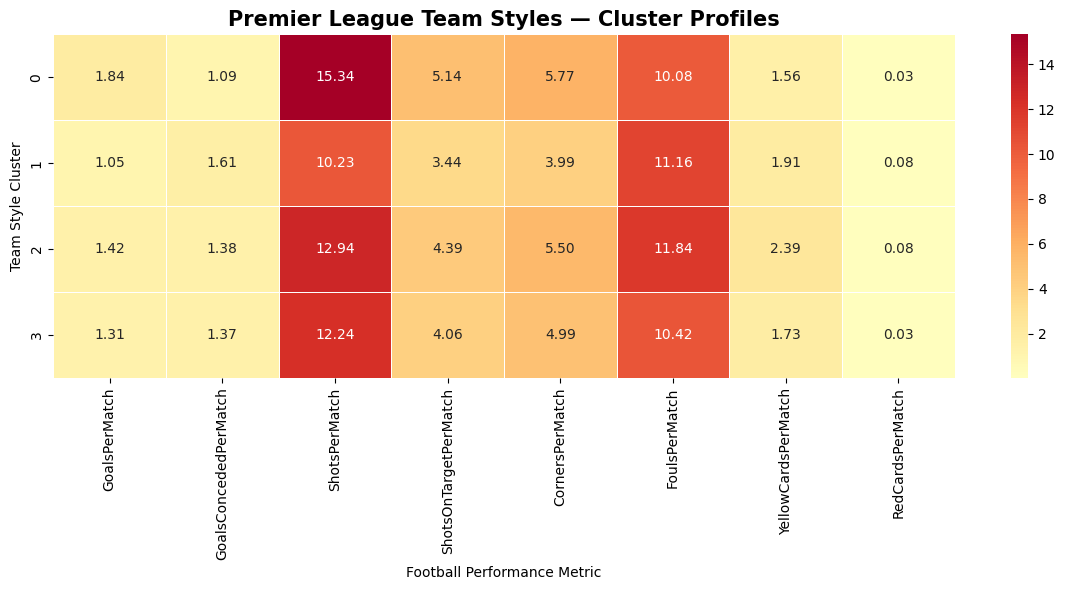

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Standardised cluster profiles
cluster_zscores = (
    style_stats.groupby("Cluster")[style_features]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_zscores,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title(
    "Premier League Team Styles — Cluster Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Football Performance Metric")
plt.ylabel("Team Style Cluster")

plt.tight_layout()
plt.show()

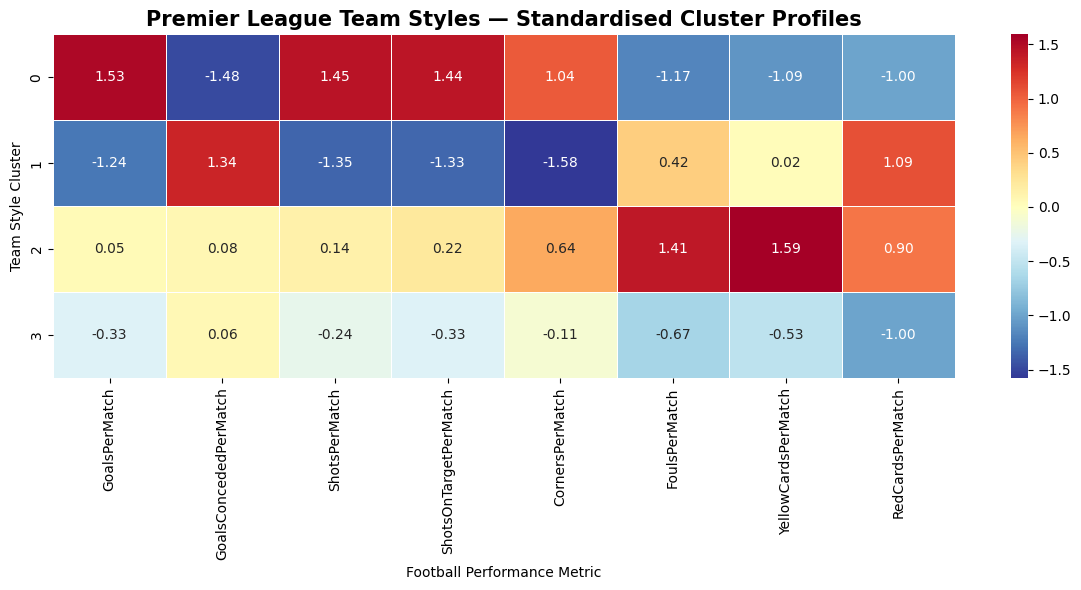

In [32]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate league-standardised cluster profiles
cluster_means = style_stats.groupby("Cluster")[style_features].mean()

scaler = StandardScaler()
cluster_zscores = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_zscores,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title(
    "Premier League Team Styles — Standardised Cluster Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Football Performance Metric")
plt.ylabel("Team Style Cluster")

plt.tight_layout()
plt.show()

In [34]:
# Give our clusters meaningful football-style names

cluster_names = {
    0: "Elite High-Output",
    1: "Low-Output / Struggling",
    2: "Aggressive High-Activity",
    3: "Balanced Mid-Profile"
}

# Add the names to our team data
style_stats["TeamStyle"] = style_stats["Cluster"].map(cluster_names)

# Display teams grouped by their football style
for cluster, name in cluster_names.items():
    teams = style_stats[
        style_stats["Cluster"] == cluster
    ]["Team"].tolist()

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(", ".join(teams))
    print()

Elite High-Output
Arsenal, Liverpool, Man City, Man United

Low-Output / Struggling
Burnley, Everton, Sunderland, West Ham, Wolves

Aggressive High-Activity
Bournemouth, Brighton, Chelsea, Tottenham

Balanced Mid-Profile
Aston Villa, Brentford, Crystal Palace, Fulham, Leeds, Newcastle, Nott'm Forest



In [35]:
print(df.columns.tolist())

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2

In [36]:
# Give our clusters meaningful football-style names

cluster_names = {
    0: "Elite High-Output",
    1: "Low-Output / Struggling",
    2: "Aggressive High-Activity",
    3: "Balanced Mid-Profile"
}

style_stats["TeamStyle"] = style_stats["Cluster"].map(cluster_names)

# Display teams grouped by football style
for cluster, name in cluster_names.items():
    teams = style_stats[
        style_stats["Cluster"] == cluster
    ]["Team"].tolist()

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(", ".join(teams))
    print()

Elite High-Output
Arsenal, Liverpool, Man City, Man United

Low-Output / Struggling
Burnley, Everton, Sunderland, West Ham, Wolves

Aggressive High-Activity
Bournemouth, Brighton, Chelsea, Tottenham

Balanced Mid-Profile
Aston Villa, Brentford, Crystal Palace, Fulham, Leeds, Newcastle, Nott'm Forest



In [37]:
style_stats[
    ["Team", "Cluster", "TeamStyle"]
].sort_values(["Cluster", "Team"])

,Team,Cluster,TeamStyle
0,Arsenal,0,Elite High-Output
11,Liverpool,0,Elite High-Output
12,Man City,0,Elite High-Output
13,Man United,0,Elite High-Output
5,Burnley,1,Low-Output / Struggling
8,Everton,1,Low-Output / Struggling
16,Sunderland,1,Low-Output / Struggling
18,West Ham,1,Low-Output / Struggling
19,Wolves,1,Low-Output / Struggling
2,Bournemouth,2,Aggressive High-Activity


In [38]:
cluster_profile = style_stats.groupby("TeamStyle")[[
    "GoalsPerMatch",
    "GoalsConcededPerMatch",
    "ShotsPerMatch",
    "ShotsOnTargetPerMatch",
    "CornersPerMatch",
    "FoulsPerMatch",
    "YellowCardsPerMatch",
    "RedCardsPerMatch"
]].mean().round(2)

cluster_profile

,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch
TeamStyle,,,,,,,,
Aggressive High-Activity,1.42,1.38,12.94,4.39,5.50,11.84,2.39,0.08
Balanced Mid-Profile,1.31,1.37,12.24,4.06,4.99,10.42,1.73,0.03
Elite High-Output,1.84,1.09,15.34,5.14,5.77,10.08,1.56,0.03
Low-Output / Struggling,1.05,1.61,10.23,3.44,3.99,11.16,1.91,0.08


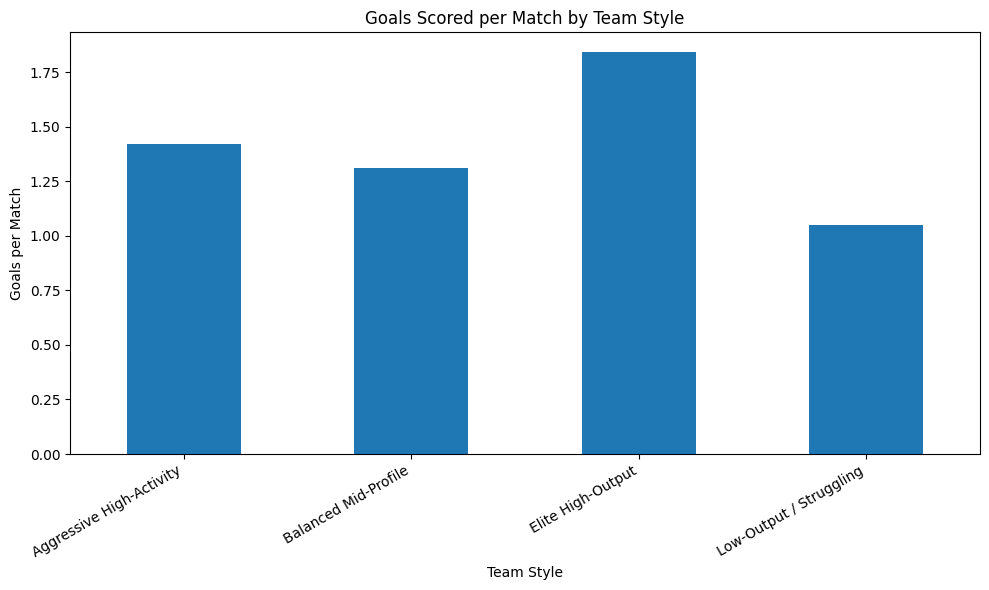

In [39]:
import matplotlib.pyplot as plt

cluster_profile["GoalsPerMatch"].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Goals Scored per Match by Team Style")
plt.xlabel("Team Style")
plt.ylabel("Goals per Match")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [40]:
style_stats[
    [
        "Team",
        "TeamStyle",
        "GoalsPerMatch",
        "ShotsPerMatch",
        "ShotsOnTargetPerMatch",
        "CornersPerMatch"
    ]
].sort_values("GoalsPerMatch", ascending=False)

,Team,TeamStyle,GoalsPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch
12,Man City,Elite High-Output,2.026316,15.657895,5.394737,6.500000
0,Arsenal,Elite High-Output,1.868421,14.526316,4.894737,5.684211
13,Man United,Elite High-Output,1.815789,15.684211,5.684211,4.789474
11,Liverpool,Elite High-Output,1.657895,15.473684,4.605263,6.105263
2,Bournemouth,Aggressive High-Activity,1.526316,13.815789,4.684211,5.578947
6,Chelsea,Aggressive High-Activity,1.526316,13.447368,4.315789,6.078947
1,Aston Villa,Balanced Mid-Profile,1.473684,12.710526,4.473684,5.236842
3,Brentford,Balanced Mid-Profile,1.447368,10.657895,3.868421,4.789474
14,Newcastle,Balanced Mid-Profile,1.394737,12.947368,4.631579,6.078947
4,Brighton,Aggressive High-Activity,1.368421,13.026316,4.631579,4.868421


In [42]:
style_stats[
    style_stats["Team"].isin(
        ["Man United", "Arsenal", "Liverpool", "Man City"]
    )
].sort_values("GoalsPerMatch", ascending=False)

,Team,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch,Cluster,PCA1,PCA2,PCA_Distance,TeamStyle
12,Man City,2.026316,0.921053,15.657895,5.394737,6.500000,9.657895,1.763158,0.000000,0,4.415301,0.229862,4.421281,Elite High-Output
0,Arsenal,1.868421,0.710526,14.526316,4.894737,5.684211,10.289474,1.342105,0.000000,0,3.608819,-0.786656,3.693562,Elite High-Output
13,Man United,1.815789,1.315789,15.684211,5.684211,4.789474,10.289474,1.631579,0.078947,0,2.551618,0.394601,2.581950,Elite High-Output
11,Liverpool,1.657895,1.394737,15.473684,4.605263,6.105263,10.078947,1.500000,0.026316,0,2.424916,-0.451952,2.466673,Elite High-Output


In [43]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=style_features,
    columns=["PCA1", "PCA2"]
)

pca_loadings.round(3)

,PCA1,PCA2
GoalsPerMatch,0.450,0.122
GoalsConcededPerMatch,-0.365,-0.062
ShotsPerMatch,0.430,0.195
ShotsOnTargetPerMatch,0.423,0.207
CornersPerMatch,0.369,0.292
FoulsPerMatch,-0.284,0.479
YellowCardsPerMatch,-0.217,0.633
RedCardsPerMatch,-0.192,0.430


In [44]:
cluster_names = {
    0: "High-Output Attack",
    1: "Low-Output / Struggling",
    2: "Aggressive High-Activity",
    3: "Balanced Mid-Profile"
}

style_stats["TeamStyle"] = style_stats["Cluster"].map(cluster_names)

style_stats[["Team", "Cluster", "TeamStyle"]].sort_values(
    ["Cluster", "Team"]
)

,Team,Cluster,TeamStyle
0,Arsenal,0,High-Output Attack
11,Liverpool,0,High-Output Attack
12,Man City,0,High-Output Attack
13,Man United,0,High-Output Attack
5,Burnley,1,Low-Output / Struggling
8,Everton,1,Low-Output / Struggling
16,Sunderland,1,Low-Output / Struggling
18,West Ham,1,Low-Output / Struggling
19,Wolves,1,Low-Output / Struggling
2,Bournemouth,2,Aggressive High-Activity


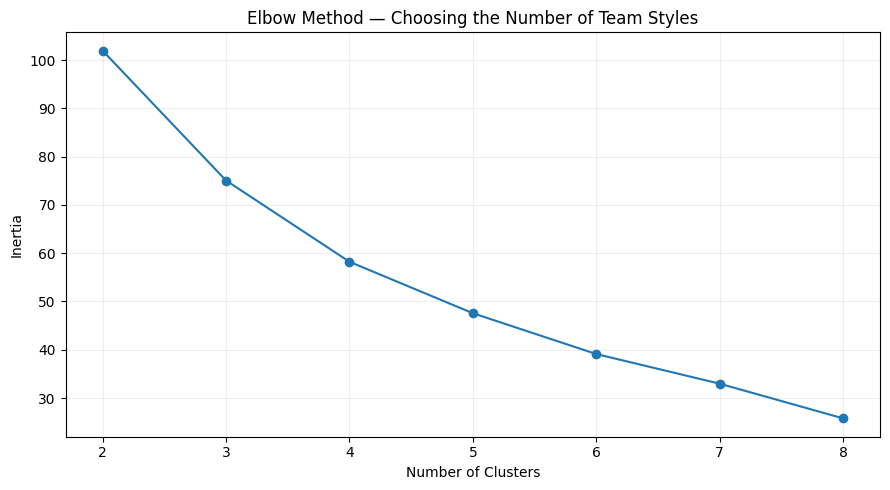

In [45]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 9), inertias, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method — Choosing the Number of Team Styles")
plt.xticks(range(2, 9))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X, style_stats["Cluster"])

print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.235


In [47]:
for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)

    print(f"{k} clusters: Silhouette Score = {score:.3f}")

2 clusters: Silhouette Score = 0.281
3 clusters: Silhouette Score = 0.286
4 clusters: Silhouette Score = 0.235
5 clusters: Silhouette Score = 0.221
6 clusters: Silhouette Score = 0.223
7 clusters: Silhouette Score = 0.195
8 clusters: Silhouette Score = 0.211


In [48]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

style_stats["Cluster_3"] = kmeans_3.fit_predict(X)

for cluster in sorted(style_stats["Cluster_3"].unique()):
    teams = style_stats[
        style_stats["Cluster_3"] == cluster
    ]["Team"].tolist()

    print("=" * 60)
    print(f"Cluster {cluster}")
    print("=" * 60)
    print(", ".join(teams))
    print()

Cluster 0
Bournemouth, Brighton, Chelsea, Tottenham

Cluster 1
Arsenal, Aston Villa, Liverpool, Man City, Man United, Newcastle

Cluster 2
Brentford, Burnley, Crystal Palace, Everton, Fulham, Leeds, Nott'm Forest, Sunderland, West Ham, Wolves



In [49]:
cluster_3_profile = style_stats.groupby("Cluster_3")[style_features].mean().round(2)

cluster_3_profile

,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch,RedCardsPerMatch
Cluster_3,,,,,,,,
0,1.42,1.38,12.94,4.39,5.50,11.84,2.39,0.08
1,1.71,1.18,14.50,4.95,5.73,10.07,1.57,0.03
2,1.16,1.49,11.12,3.65,4.36,10.86,1.85,0.05


In [50]:
scores = []

for seed in range(10):
    model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=10
    )

    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

print("Silhouette scores across 10 runs:")
print([round(score, 3) for score in scores])
print(f"\nAverage: {sum(scores) / len(scores):.3f}")

Silhouette scores across 10 runs:
[np.float64(0.286), np.float64(0.286), np.float64(0.286), np.float64(0.286), np.float64(0.286), np.float64(0.286), np.float64(0.277), np.float64(0.286), np.float64(0.256), np.float64(0.268)]

Average: 0.280


In [51]:
cluster_3_names = {
    0: "Aggressive High-Activity",
    1: "High-Output / Strong Performance",
    2: "Lower-Output / Struggling"
}

style_stats["FinalStyle"] = style_stats["Cluster_3"].map(cluster_3_names)

style_stats[
    ["Team", "Cluster_3", "FinalStyle"]
].sort_values(["Cluster_3", "Team"])

,Team,Cluster_3,FinalStyle
2,Bournemouth,0,Aggressive High-Activity
4,Brighton,0,Aggressive High-Activity
6,Chelsea,0,Aggressive High-Activity
17,Tottenham,0,Aggressive High-Activity
0,Arsenal,1,High-Output / Strong Performance
1,Aston Villa,1,High-Output / Strong Performance
11,Liverpool,1,High-Output / Strong Performance
12,Man City,1,High-Output / Strong Performance
13,Man United,1,High-Output / Strong Performance
14,Newcastle,1,High-Output / Strong Performance


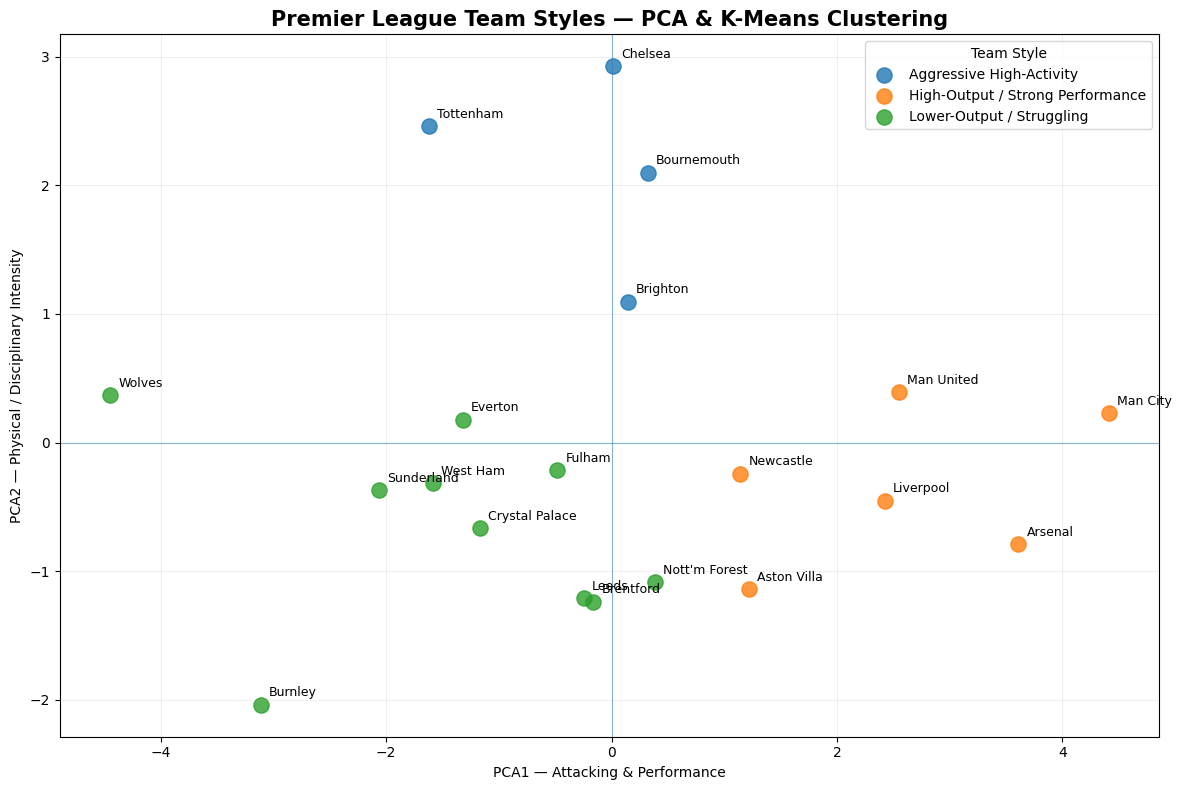

In [52]:
plt.figure(figsize=(12, 8))

for cluster in sorted(style_stats["Cluster_3"].unique()):
    cluster_data = style_stats[
        style_stats["Cluster_3"] == cluster
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        s=120,
        label=cluster_3_names[cluster],
        alpha=0.8
    )

    for _, row in cluster_data.iterrows():
        plt.annotate(
            row["Team"],
            (row["PCA1"], row["PCA2"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

plt.axhline(0, linewidth=0.8, alpha=0.5)
plt.axvline(0, linewidth=0.8, alpha=0.5)

plt.xlabel("PCA1 — Attacking & Performance")
plt.ylabel("PCA2 — Physical / Disciplinary Intensity")

plt.title(
    "Premier League Team Styles — PCA & K-Means Clustering",
    fontsize=15,
    fontweight="bold"
)

plt.legend(title="Team Style")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [53]:
final_profile = style_stats.groupby("FinalStyle")[[
    "GoalsPerMatch",
    "GoalsConcededPerMatch",
    "ShotsPerMatch",
    "ShotsOnTargetPerMatch",
    "CornersPerMatch",
    "FoulsPerMatch",
    "YellowCardsPerMatch"
]].mean().round(2)

final_profile

,GoalsPerMatch,GoalsConcededPerMatch,ShotsPerMatch,ShotsOnTargetPerMatch,CornersPerMatch,FoulsPerMatch,YellowCardsPerMatch
FinalStyle,,,,,,,
Aggressive High-Activity,1.42,1.38,12.94,4.39,5.50,11.84,2.39
High-Output / Strong Performance,1.71,1.18,14.50,4.95,5.73,10.07,1.57
Lower-Output / Struggling,1.16,1.49,11.12,3.65,4.36,10.86,1.85


In [54]:
final_team_styles = style_stats[
    ["Team", "FinalStyle"]
].sort_values("FinalStyle")

final_team_styles

,Team,FinalStyle
2,Bournemouth,Aggressive High-Activity
17,Tottenham,Aggressive High-Activity
4,Brighton,Aggressive High-Activity
6,Chelsea,Aggressive High-Activity
0,Arsenal,High-Output / Strong Performance
1,Aston Villa,High-Output / Strong Performance
14,Newcastle,High-Output / Strong Performance
13,Man United,High-Output / Strong Performance
12,Man City,High-Output / Strong Performance
11,Liverpool,High-Output / Strong Performance


In [55]:
final_team_styles.to_csv(
    "final_team_styles.csv",
    index=False
)

print("Saved: final_team_styles.csv")

Saved: final_team_styles.csv


In [56]:
from google.colab import files

files.download("final_team_styles.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
final_profile = style_stats.groupby("FinalStyle")[
    [
        "GoalsPerMatch",
        "GoalsConcededPerMatch",
        "ShotsPerMatch",
        "ShotsOnTargetPerMatch",
        "CornersPerMatch",
        "FoulsPerMatch",
        "YellowCardsPerMatch"
    ]
].mean().round(2)

final_profile.to_csv("team_style_profiles.csv")

print("Saved: team_style_profiles.csv")

Saved: team_style_profiles.csv


In [58]:
from google.colab import files
files.download("team_style_profiles.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>